# IVAN — Matrix Regression (ERT `.dat` → target `.npz`)

Актуальная задача:

- **Вход:** `.dat` (ERT измерения)
- **Выход модели:** 2D float-матрица размера **(300, 600)**
- **Таргет:** `.npz` (2D matrix)
- **Нормализация таргета:** внутри `iternet.preprocessing` (signed-log + scale to [-1,1])
- **Визуализация:** grayscale

In [1]:
# 0) Imports
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import torch
from torch.utils.data import DataLoader

from iternet.config import DataConfig, GridConfig, ModelConfig, TrainConfig
from iternet.data_discovery import discover_train_test
from iternet.dataset import IternetDataset, collate_batch, collate_single
from iternet.model import IternetPerceiver
from iternet.pipeline import open_training_data, preprocess_data, init_model, predict_mask
from iternet.train import train_segmentation
from iternet.viz import plot_target_vs_prediction

In [10]:
# 1) Paths and global configs
DATA_DIR = Path(r"C:\Max\Proga\IVAN\data\processed")

# Target matrix size (Z, X)
NZ, NX = 300, 600

GRID = GridConfig(
    look_nx=NX,
    look_nz=NZ,
    x_min=-300.0,
    x_max=300.0,
    z_min=0.0,
    z_max=150.0,
)

MODEL_CFG = ModelConfig(
    out_channels=1,
    token_dim = 128,
    latent_dim = 128,
    num_latents = 16,
    num_layers = 6,
    num_heads = 4,
)

TRAIN_CFG = TrainConfig(
    epochs=10,
    batch_size=16,
    lr=3e-4,
    weight_decay=1e-4,
    device="cuda" if torch.cuda.is_available() else "cpu",
    log_dir=Path("iternet/runs"),
)

print("DATA_DIR:", DATA_DIR)
print("DEVICE:", TRAIN_CFG.device)
print("GRID (Z,X):", GRID.look_nz, GRID.look_nx)

DATA_DIR: C:\Max\Proga\IVAN\data\processed
DEVICE: cuda
GRID (Z,X): 300 600


In [3]:
# 5) Init model
# В текущем режиме модель получает только вектор (1578,) значений => in_features=1.
in_features = 1

model = IternetPerceiver(
    in_features=in_features,
    token_dim=MODEL_CFG.token_dim,
    latent_dim=MODEL_CFG.latent_dim,
    num_latents=MODEL_CFG.num_latents,
    num_layers=MODEL_CFG.num_layers,
    num_heads=MODEL_CFG.num_heads,
    out_channels=MODEL_CFG.out_channels,
    dropout=MODEL_CFG.dropout,
)

# total / trainable params
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print("Total params:", total_params)
print("Trainable params:", trainable_params)

Total params: 1415297
Trainable params: 1415297


In [4]:
# 2) Discover train/test pairs (.dat + .npz)
train_pairs, test_pairs = discover_train_test(DATA_DIR)
print(f"Train pairs: {len(train_pairs)}")
print(f"Test pairs : {len(test_pairs)}")

train_pairs[:3] if train_pairs else None

Train pairs: 223
Test pairs : 25


[SamplePaths(ie2d_res=WindowsPath('C:/Max/Proga/IVAN/data/processed/train/electrical_resistivity_tomography/026.dat'), target_matrix=WindowsPath('C:/Max/Proga/IVAN/data/processed/train/models/026.npz')),
 SamplePaths(ie2d_res=WindowsPath('C:/Max/Proga/IVAN/data/processed/train/electrical_resistivity_tomography/027.dat'), target_matrix=WindowsPath('C:/Max/Proga/IVAN/data/processed/train/models/027.npz')),
 SamplePaths(ie2d_res=WindowsPath('C:/Max/Proga/IVAN/data/processed/train/electrical_resistivity_tomography/028.dat'), target_matrix=WindowsPath('C:/Max/Proga/IVAN/data/processed/train/models/028.npz'))]

In [5]:
# # 3) Sanity-check: load one sample via pipeline and visualize target vs (untrained) prediction
# # Важно: тут НЕ проверяем чекпоинт, потому что его может не быть.

# if not train_pairs:
#     raise RuntimeError("No train pairs found. Check data/processed layout.")

# one = train_pairs[0]
# DATA_ONE = DataConfig(
#     ie2d_res_path=one.ie2d_res,
#     target_matrix_path=one.target_matrix,
#     value_kind="auto",
#     current_a=1.0,
# )
# raw_one = open_training_data(DATA_ONE)
# prep_one = preprocess_data(raw_one, GRID)

# print("meas_values_01:", tuple(prep_one.sample.meas_values_01.shape))
# print("target_norm:", tuple(prep_one.sample.target_matrix_norm.shape))
# print("target_raw:", tuple(prep_one.sample.target_matrix_raw.shape))

# # Untrained model prediction (only to test that shapes work)
# model_untrained = init_model(prep_one, MODEL_CFG)
# pred_untrained = predict_mask(model_untrained, prep_one, device=TRAIN_CFG.device)
# target_raw = prep_one.sample.target_matrix_raw

# fig = plot_target_vs_prediction(
#     target_raw,
#     pred_untrained,
#     title="Sanity check (untrained): target vs prediction",
#     x_coords=prep_one.sample.x_coords,
#     z_coords=prep_one.sample.z_coords,
# )
# plt.show()

In [6]:
# 4) Build datasets and loaders
# Train loader: shuffle=True
train_ds = IternetDataset(
    samples=train_pairs,
    nx=GRID.look_nx,
    nz=GRID.look_nz,
    grid_overrides={"x_min": GRID.x_min, "x_max": GRID.x_max, "z_min": GRID.z_min, "z_max": GRID.z_max},
)
val_ds = IternetDataset(
    samples=test_pairs,
    nx=GRID.look_nx,
    nz=GRID.look_nz,
    grid_overrides={"x_min": GRID.x_min, "x_max": GRID.x_max, "z_min": GRID.z_min, "z_max": GRID.z_max},
) if test_pairs else None

train_loader = DataLoader(
    train_ds,
    batch_size=TRAIN_CFG.batch_size,
    shuffle=True,
    collate_fn=collate_batch if TRAIN_CFG.batch_size > 1 else collate_single,
    num_workers=0,
)
val_loader = DataLoader(
    val_ds,
    batch_size=1,
    shuffle=False,
    collate_fn=collate_single,
    num_workers=0,
) if val_ds is not None else None

print("Train batches:", len(train_loader))
print("Val batches  :", len(val_loader) if val_loader is not None else 0)

Train batches: 14
Val batches  : 25


In [11]:
# 6) Train (regression)
# Логи: iternet/runs/<timestamp> (TensorBoard + val_images)
config_dict = {
    "data_dir": str(DATA_DIR),
    "nx": NX,
    "nz": NZ,
    "x_min": GRID.x_min,
    "x_max": GRID.x_max,
    "z_min": GRID.z_min,
    "z_max": GRID.z_max,
    "epochs": TRAIN_CFG.epochs,
    "batch_size": TRAIN_CFG.batch_size,
    "lr": TRAIN_CFG.lr,
    "weight_decay": TRAIN_CFG.weight_decay,
    "device": TRAIN_CFG.device,
}

history = train_segmentation(
    model=model,
    loader=train_loader,
    epochs=TRAIN_CFG.epochs,
    lr=TRAIN_CFG.lr,
    weight_decay=TRAIN_CFG.weight_decay,
    device=TRAIN_CFG.device,
    log_dir=TRAIN_CFG.log_dir,
    val_loader=val_loader,
    log_every_steps=TRAIN_CFG.log_every_steps,
    config_dict=config_dict,
)

print("Final train loss:", history.losses[-1] if history.losses else None)
print("Final train rmse:", history.rmse[-1] if history.rmse else None)
if history.val_rmse:
    print("Final val rmse:", history.val_rmse[-1])

TensorBoard logs: iternet\runs\2026-02-27_21-36-15
Config logged to TensorBoard


Epochs: 100%|██████████| 10/10 [02:45<00:00, 16.59s/ep, loss=0.7421, val_rmse=0.808]

Final train loss: 0.7821795344352722
Final train rmse: 0.8414182066917419
Final val rmse: 0.8083384251594543


In [12]:
# 7) Save checkpoint (after training)
# Формат: {'model': state_dict, 'out_channels': 1, 'in_features': 1}
CKPT_OUT = Path("iternet/runs") / "model_regression.pt"
CKPT_OUT.parent.mkdir(parents=True, exist_ok=True)

torch.save(
    {
        "model": model.state_dict(),
        "out_channels": MODEL_CFG.out_channels,
        "in_features": in_features,
    },
    CKPT_OUT,
)

print("Saved:", CKPT_OUT)

Saved: iternet\runs\model_regression.pt


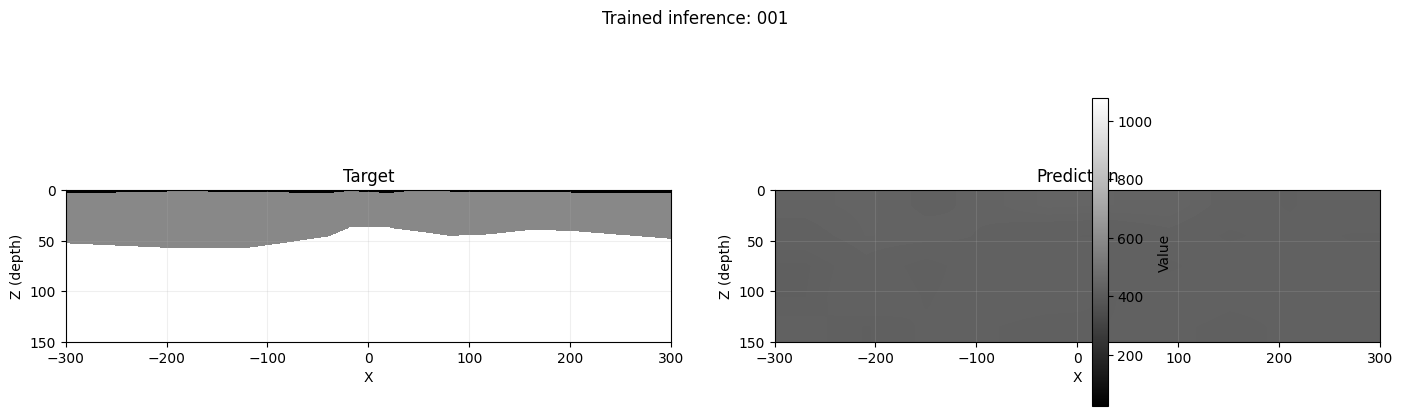

MAE : 498.480103
RMSE: 548.001587
MAPE: 70.328%
R2  : -3.950796


In [13]:
# 8) Test inference on a trained checkpoint (optional)
# ВАЖНО: проверка наличия чекпоинта делается только здесь.

CHECKPOINT_PATH = CKPT_OUT  # можно заменить на путь к любому *.pt

if not CHECKPOINT_PATH.exists():
    print(f"Checkpoint not found: {CHECKPOINT_PATH}")
    print("Skip this section. Train first or set CHECKPOINT_PATH to an existing file.")
else:
    # Pick a sample (prefer test if available)
    sample = test_pairs[0] if test_pairs else train_pairs[0]
    DATA_TEST = DataConfig(
        ie2d_res_path=sample.ie2d_res,
        target_matrix_path=sample.target_matrix,
        value_kind="auto",
        current_a=1.0,
    )
    raw_t = open_training_data(DATA_TEST)
    prep_t = preprocess_data(raw_t, GRID)

    model_t = init_model(prep_t, MODEL_CFG, checkpoint_path=CHECKPOINT_PATH, strict=True)
    pred = predict_mask(model_t, prep_t, device=TRAIN_CFG.device)
    target = prep_t.sample.target_matrix_raw

    # Visualization
    fig = plot_target_vs_prediction(
        target,
        pred,
        title=f"Trained inference: {sample.target_matrix.stem}",
        x_coords=prep_t.sample.x_coords,
        z_coords=prep_t.sample.z_coords,
    )
    plt.show()

    # Metrics
    err = pred - target
    mae = float(np.mean(np.abs(err)))
    rmse = float(np.sqrt(np.mean(err ** 2)))
    den = np.maximum(np.abs(target), 1e-6)
    mape = float(np.mean(np.abs(err) / den) * 100.0)
    ss_res = float(np.sum(err ** 2))
    ss_tot = float(np.sum((target - np.mean(target)) ** 2))
    r2 = 1.0 - ss_res / (ss_tot + 1e-12)

    print(f"MAE : {mae:.6f}")
    print(f"RMSE: {rmse:.6f}")
    print(f"MAPE: {mape:.3f}%")
    print(f"R2  : {r2:.6f}")

## TensorBoard

```bash
tensorboard --logdir iternet/runs
```

Валидационные картинки сохраняются рядом с логами в:

- `iternet/runs/<timestamp>/val_images/epoch_0000/`, `epoch_0001/`, ...